# HST Morphological Mapping Pipeline — Inference

This notebook runs the inference pipeline for the self-supervised morphological
mapping of HST drizzled (DRZ) images, as described in the paper.

## Pipeline Overview

**Pipeline 1 (MAP1) — Source-level clustering:**
1. Run SExtractor on each FITS image to detect sources
2. Extract 128×128 cutouts around each detected source
3. Encode cutouts with VICReg-128 → 128-dim embedding per source
4. Cluster embeddings with DEC-400 → assign each source to one of 400 morphological classes
5. Compute a 400-dim "fingerprint" histogram per image (distribution of source types)

**Pipeline 2 (MAP2) — Image-level clustering:**
1. Resize full FITS image to 256×256, encode with VICReg-256 → 128-dim global embedding
2. Concatenate global embedding (128) + log-fingerprint (400) → 528-dim combined vector
3. StandardScaler normalize → VAE compress to 128-dim → DEC-144 final cluster assignment

The final output places each FITS image at a position on a 12×12 grid (MAP2),
where nearby positions correspond to morphologically similar fields.

## 0. Setup & Imports

All imports are collected here. Helper functions and model definitions live in
`pipeline_helpers.py` to keep this notebook focused on the pipeline flow.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as TF
from astropy.visualization import ZScaleInterval
from PIL import Image
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from tqdm import tqdm

# Local helpers (same directory as this notebook)
from pipeline_helpers import (
    CutoutDataset,
    extract_cutouts,
    load_dec_map1,
    load_dec_map2,
    load_fits_science_image,
    load_vae,
    load_vicreg_model,
    normalize_cutouts,
    normalize_single_image,
    resize_to_256,
    run_sextractor,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Configuration

All file paths and hyperparameters are defined here in one place.
Paths are relative to this notebook's directory — no edits needed if you
cloned the repository and kept the folder structure intact.

In [2]:
# ── Base directory (root of this repository) ──
BASE_DIR = Path.cwd()  # assumes notebook is run from the pipeline/ folder

# ── Data directories ──
DATA_DIR    = BASE_DIR / "data"
FITS_DIR    = DATA_DIR / "fits"       # input FITS files go here
CUTOUTS_DIR = DATA_DIR / "cutouts"    # extracted cutouts saved here

# ── Model checkpoints (all in one place) ──
MODELS_DIR       = BASE_DIR / "models"
VICREG_128_CKPT  = MODELS_DIR / "vicreg_encoder_rotinv_dim128_128px_Epoch_100it_42k.pth"
DEC_MAP1_CKPT    = MODELS_DIR / "train_latents_dec_model.pt"
VICREG_256_CKPT  = MODELS_DIR / "vicreg_encoder_rotinv_dim256_256px_Epoch_200.pth"
VAE_CKPT         = MODELS_DIR / "vae_compressor_best.pth"
DEC_MAP2_CKPT    = MODELS_DIR / "dec_map2_model.pth"
MAP2_SCALER_PATH = MODELS_DIR / "scaler_528.pkl"
MAP2_GRID_LAYOUT = MODELS_DIR / "map2_cluster_to_cell.json"

# ── SExtractor (must be installed separately — see README) ──
SEXTRACTOR_BIN = "sex"          # assumes 'sex' is on your PATH
NNW_FILE       = str(MODELS_DIR / "default.nnw")  # ship the .nnw with models if needed

# ── Hyperparameters ──
LATENT_DIM   = 128   # VICReg embedding dimension
FP_DIM       = 400   # Number of MAP1 clusters (fingerprint dimension)
COMBINED_DIM = 528   # 128 (VICReg-256) + 400 (fingerprint)
DEC_K_MAP2   = 144   # Number of MAP2 clusters
BATCH_SIZE   = 256
NUM_WORKERS  = 0

## 2. Load FITS Files

Discover all DRZ FITS files in the input directory and preview them.

In [3]:
fits_files = sorted(FITS_DIR.glob("*_drz.fits"))
fits_path_map = {f.stem: f for f in fits_files}
print(f"Found {len(fits_files)} FITS files:")
for f in fits_files:
    print(f"  {f.name}")

Found 3 FITS files:
  j6m916030_drz.fits
  jb5d26010_drz.fits
  jdxr19010_drz.fits


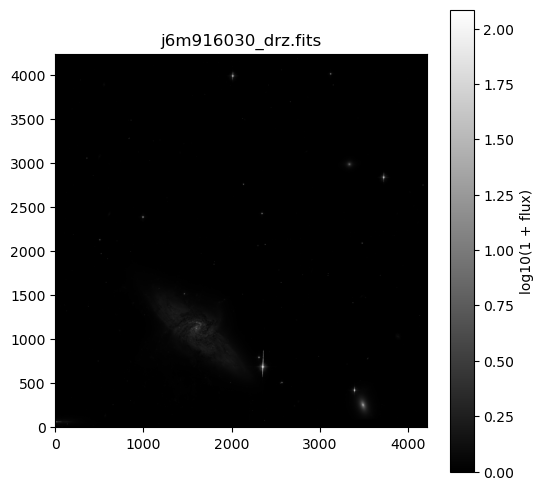

  shape=(4241, 4220), min=-0.33, max=121.04



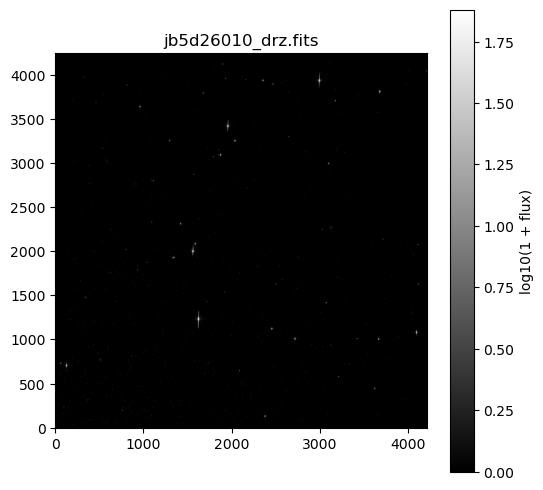

  shape=(4244, 4218), min=-1.20, max=74.95



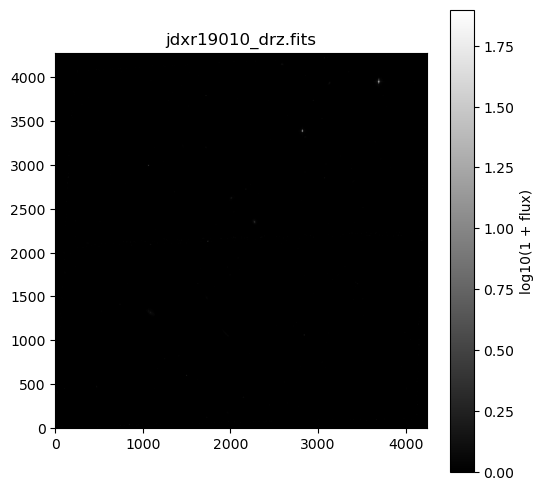

  shape=(4278, 4246), min=-19.00, max=78.34



In [4]:
# Quick preview of each FITS file
for fits_path in fits_files:
    sci = load_fits_science_image(fits_path)
    img_display = np.log10(1 + np.clip(sci, 0, None))

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display, cmap="gray", origin="lower")
    plt.colorbar(label="log10(1 + flux)")
    plt.title(fits_path.name)
    plt.show()
    print(f"  shape={sci.shape}, min={sci.min():.2f}, max={sci.max():.2f}\n")

---
# PIPELINE 1: Source-Level Clustering (MAP1)

## 3. Source Detection & Cutout Extraction

Run SExtractor to detect sources, then extract 128×128 cutouts around each.
Results are saved to `CUTOUTS_DIR/<stem>/cutouts.npy`.

**Skip this cell if cutouts have already been extracted.**

In [5]:
# Uncomment to run SExtractor + cutout extraction (only needed once)

# CUTOUTS_DIR.mkdir(exist_ok=True)
# for fits_path in fits_files:
#     stem = fits_path.stem
#     work_dir = CUTOUTS_DIR / stem
#     work_dir.mkdir(exist_ok=True)
#
#     catalog_txt = run_sextractor(str(fits_path), str(work_dir), SEXTRACTOR_BIN, NNW_FILE)
#     cutouts, se_params = extract_cutouts(str(fits_path), catalog_txt)
#
#     np.save(str(work_dir / "cutouts.npy"), cutouts)
#     np.save(str(work_dir / "se_params.npy"), se_params)
#     print(f"{stem}: {cutouts.shape[0]} cutouts saved")

## 4. Load Saved Cutouts

Load previously extracted cutouts from disk into a dictionary keyed by FITS file stem.

In [6]:
all_cutouts = {}
for folder in sorted(CUTOUTS_DIR.iterdir()):
    if folder.is_dir() and (folder / "cutouts.npy").exists() and "old" not in folder.name:
        cutouts = np.load(str(folder / "cutouts.npy"))
        all_cutouts[folder.name] = cutouts
        print(f"{folder.name}: {cutouts.shape}")

print(f"\nTotal: {len(all_cutouts)} image(s) loaded")

j6m916030_drz: (200, 128, 128)
jb5d26010_drz: (200, 128, 128)
jdxr19010_drz: (166, 128, 128)

Total: 3 image(s) loaded


## 5. Visualize Sample Cutouts

Display a 4×4 grid of random cutouts from the first FITS file to verify extraction quality.

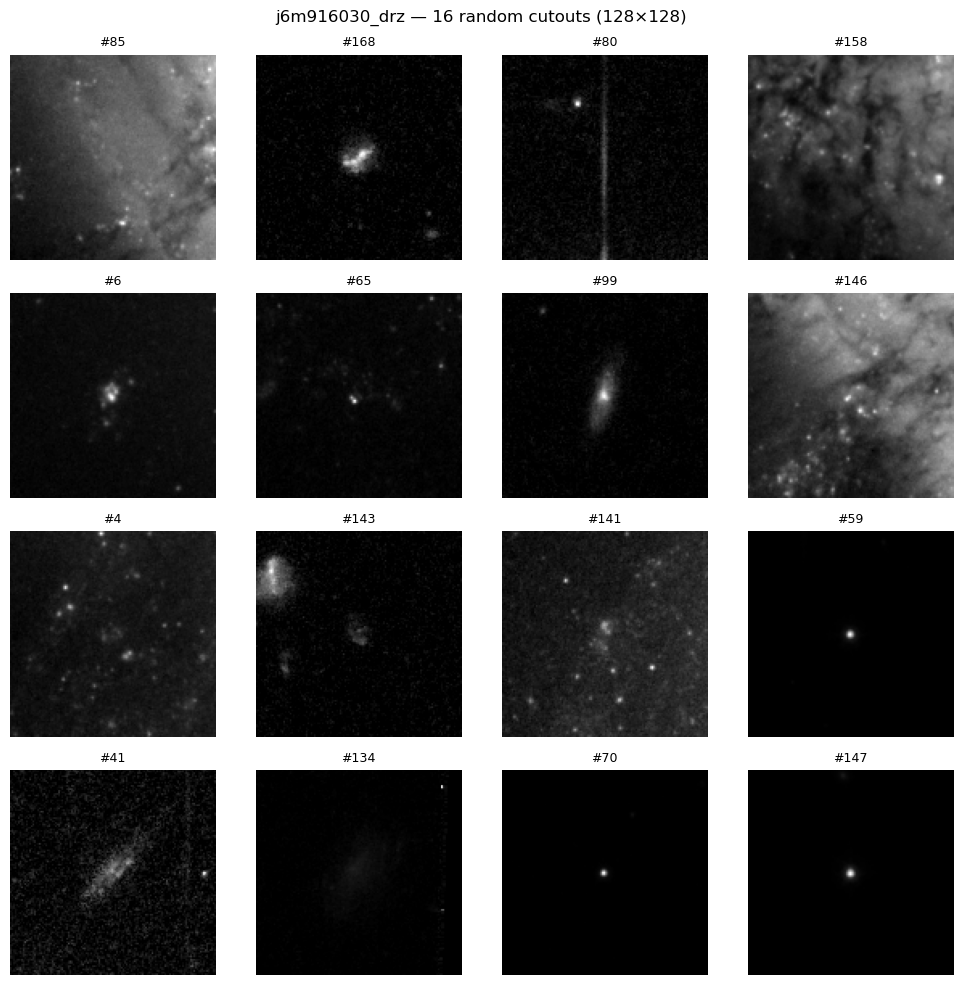

In [7]:
stem = list(all_cutouts.keys())[0]
cutouts = all_cutouts[stem]

indices = np.random.choice(len(cutouts), size=min(16, len(cutouts)), replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < len(indices):
        ax.imshow(np.log10(1 + np.clip(cutouts[indices[i]], 0, None)),
                  cmap="gray", origin="lower")
        ax.set_title(f"#{indices[i]}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"{stem} — 16 random cutouts (128×128)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. VICReg-128 Encoding

Encode each cutout through VICReg-128 to produce a 128-dimensional embedding.
This captures the morphological features of each individual source.

In [8]:
# Load VICReg-128 model
vicreg_128 = load_vicreg_model(VICREG_128_CKPT, LATENT_DIM, device)
print(f"VICReg-128 loaded: projection_dim={LATENT_DIM}")

VICReg-128 loaded: projection_dim=128


In [9]:
# Encode all cutouts → embeddings
all_embs = {}
all_imgs_normed = {}  # normalized images for visualization later

for stem, raw_cutouts in all_cutouts.items():
    # Normalize cutouts (percentile clip + min-max)
    imgs = raw_cutouts.astype(np.float32).copy()
    imgs = normalize_cutouts(imgs)
    all_imgs_normed[stem] = imgs

    # Create DataLoader
    dataset = CutoutDataset(imgs)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

    # Run inference
    embs = np.zeros((len(imgs), LATENT_DIM), dtype=np.float32)
    with torch.no_grad():
        offset = 0
        for x in tqdm(loader, desc=f"VICReg-128 [{stem}]"):
            x = x.to(device, non_blocking=True)
            z = vicreg_128(x).cpu().numpy()
            embs[offset:offset + len(z)] = z
            offset += len(z)

    all_embs[stem] = embs
    print(f"  {stem}: embeddings shape = {embs.shape}")

VICReg-128 [j6m916030_drz]: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


  j6m916030_drz: embeddings shape = (200, 128)


VICReg-128 [jb5d26010_drz]: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]


  jb5d26010_drz: embeddings shape = (200, 128)


VICReg-128 [jdxr19010_drz]: 100%|██████████| 1/1 [00:01<00:00,  1.64s/it]

  jdxr19010_drz: embeddings shape = (166, 128)


## 7. DEC-400 Clustering (MAP1)

Assign each cutout embedding to one of 400 morphological clusters using Deep Embedded Clustering.
This creates per-source labels and the per-image fingerprint histogram.

In [10]:
# Load DEC-400 model
dec_map1, K_MAP1 = load_dec_map1(DEC_MAP1_CKPT, device)
print(f"DEC MAP1 loaded: K={K_MAP1} clusters")

DEC MAP1 loaded: K=400 clusters


In [11]:
# Assign cluster labels to each cutout
all_labels = {}
all_fingerprints = {}

for stem, embs in all_embs.items():
    with torch.no_grad():
        output = dec_map1(torch.from_numpy(embs).to(device))
        q = output[0]  # DECHead returns (q, z)
        labels = torch.argmax(q, dim=1).cpu().numpy().astype(np.int64)

    # Fingerprint: histogram of cluster assignments
    fingerprint = np.bincount(labels, minlength=K_MAP1).astype(np.float32)

    all_labels[stem] = labels
    all_fingerprints[stem] = fingerprint
    print(f"{stem}: {len(labels)} sources → {len(np.unique(labels))} unique clusters used")

j6m916030_drz: 200 sources → 88 unique clusters used
jb5d26010_drz: 200 sources → 29 unique clusters used
jdxr19010_drz: 166 sources → 68 unique clusters used


## 8. Visualize MAP1 Grid

Display the 20×20 MAP1 grid showing one representative cutout per cluster.
Green labels = clusters with sources from this image. Red = empty clusters.

**Note:** This shows the *raw* (un-reorganized) MAP1 grid, where cluster IDs are
mapped directly to grid positions. The paper also presents a topology-aware
reorganized version (via UMAP + Hungarian assignment) where morphologically similar
clusters occupy adjacent cells. Both versions are shown in the paper; the raw version
is displayed here.

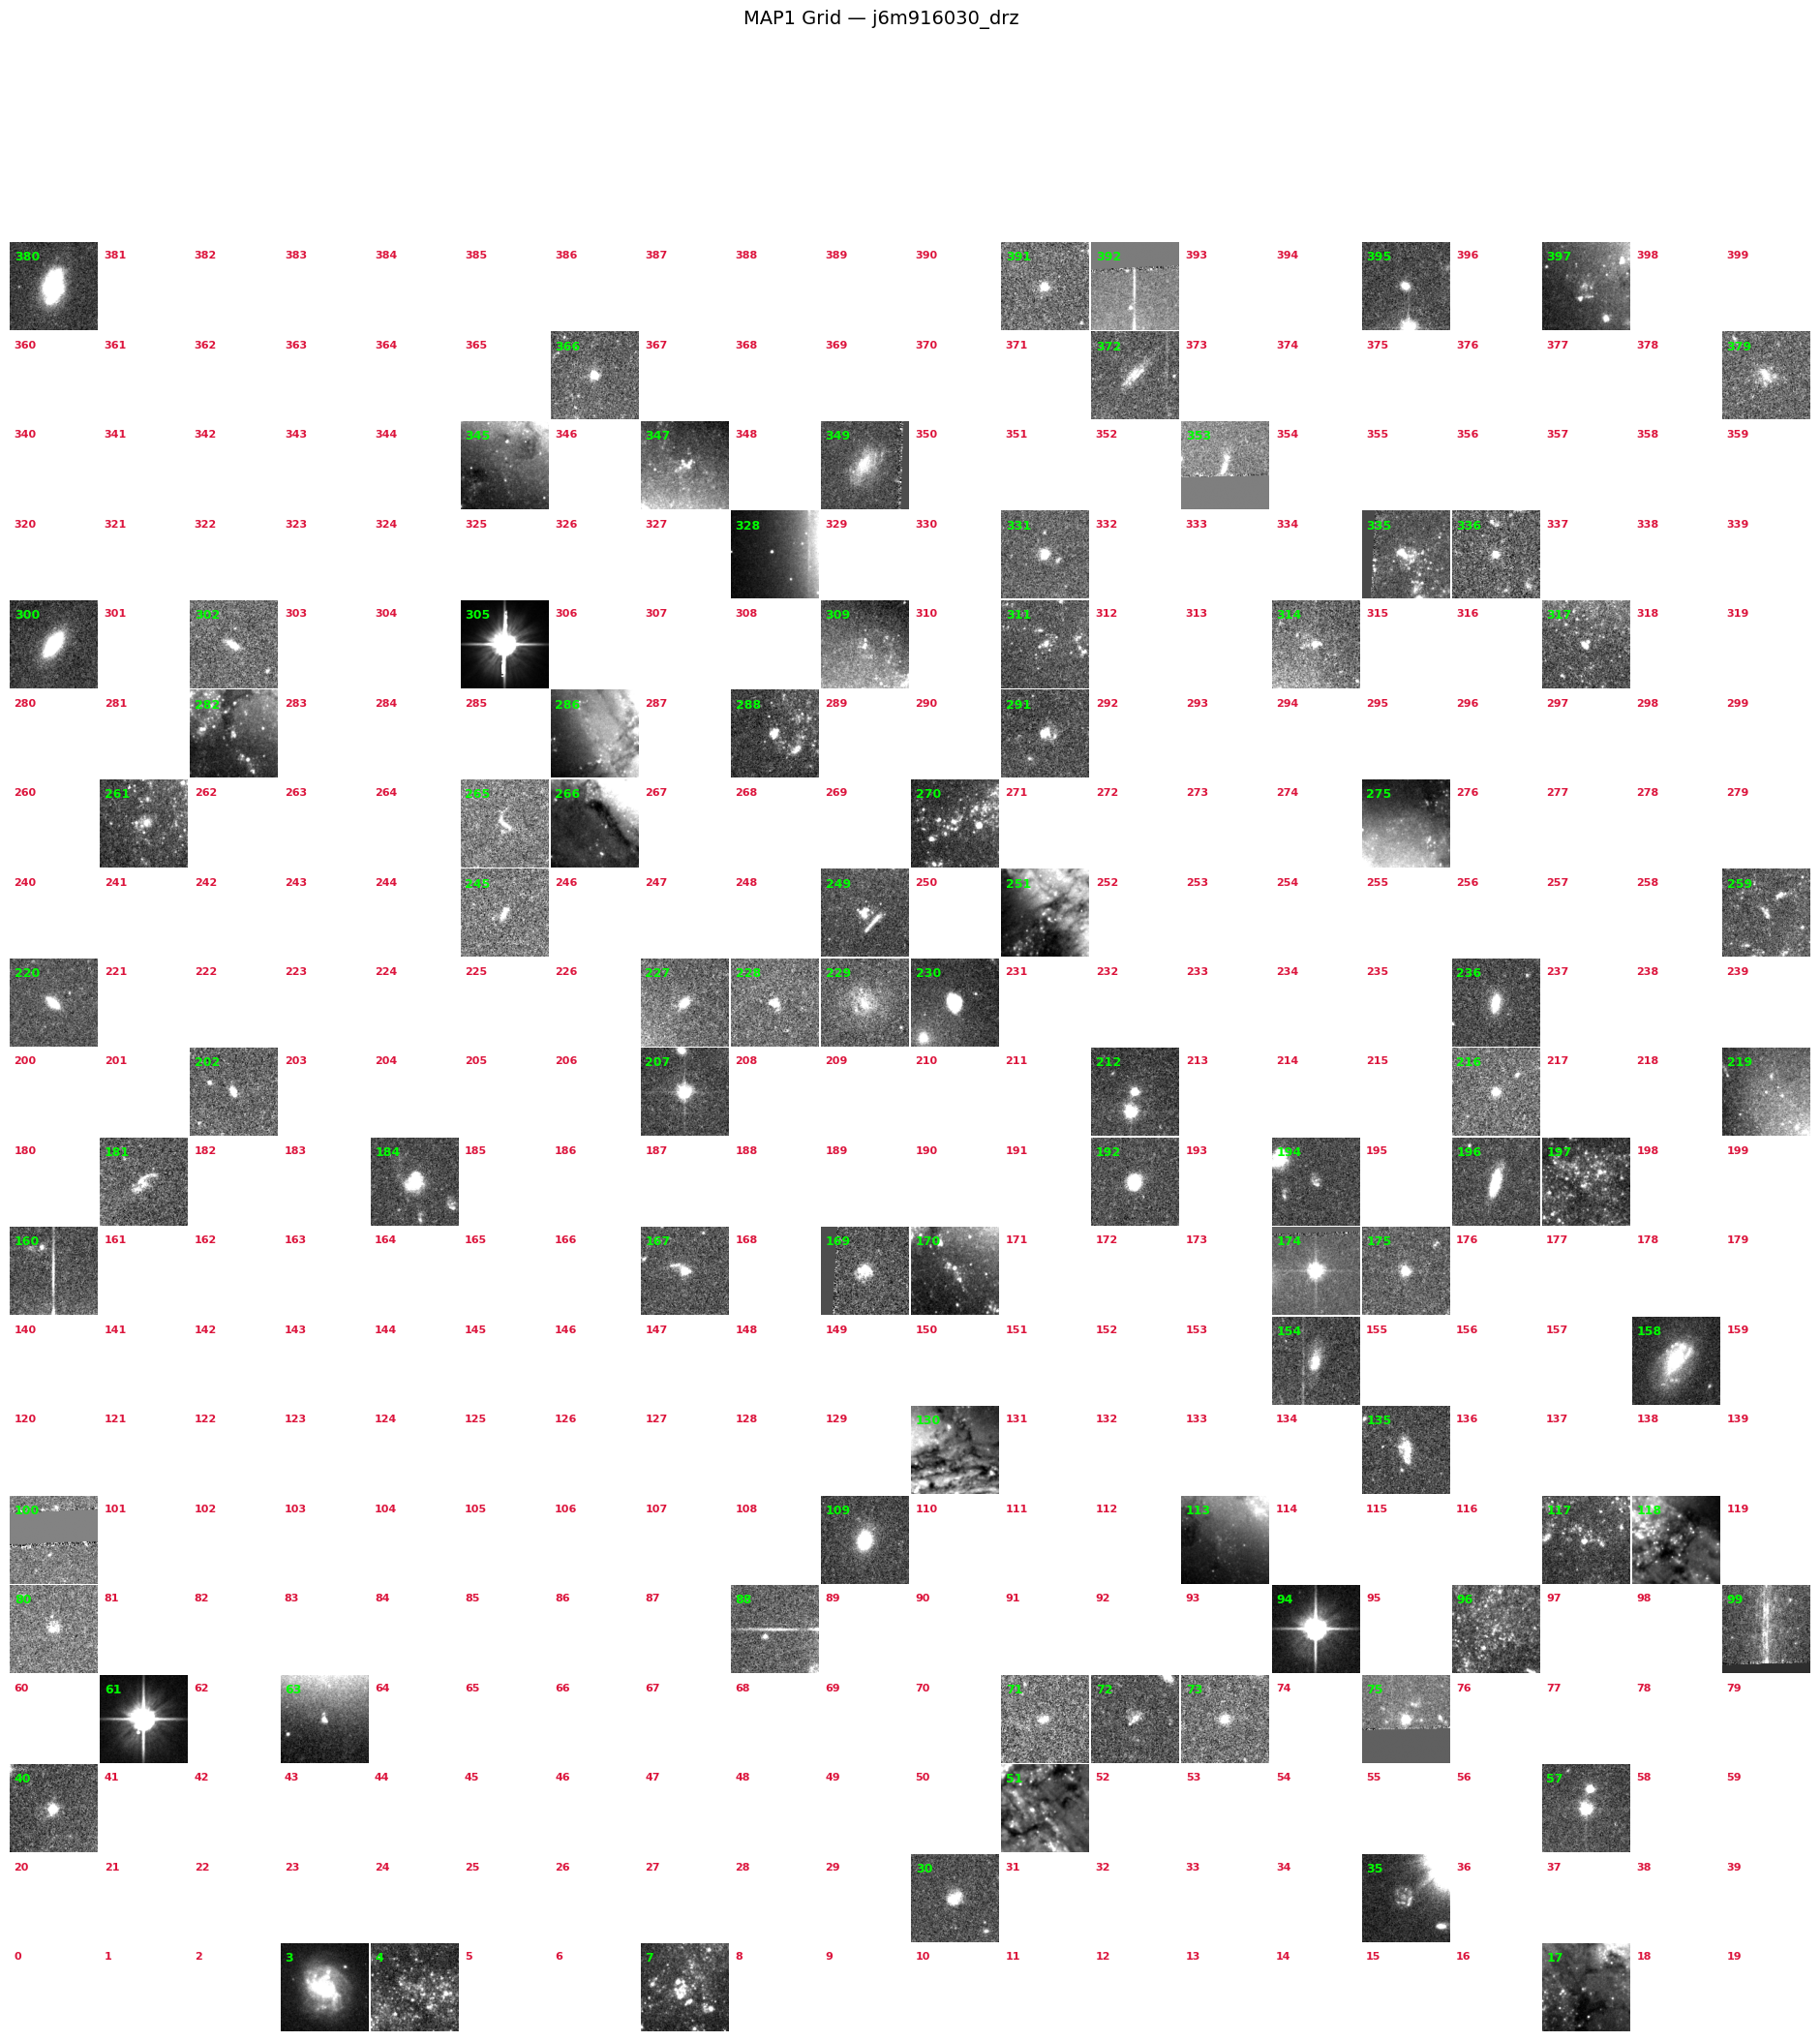

In [12]:
# Choose which FITS file to visualize
chosen_stem = list(all_labels.keys())[0]

grid_x, grid_y = 20, 20
interval = ZScaleInterval()
rng = np.random.default_rng(0)

# Build cell → cutout index mapping
cell2idx = {}
for n, k in enumerate(all_labels[chosen_stem]):
    i, j = int(k) % grid_x, int(k) // grid_x
    cell2idx.setdefault((i, j), []).append(n)

# Plot
fig, axes = plt.subplots(grid_y, grid_x, figsize=(grid_x * 1.2, grid_y * 1.2))
for i in range(grid_x):
    for j in range(grid_y):
        ax = axes[grid_y - 1 - j, i]
        ax.axis("off")
        hits = cell2idx.get((i, j), [])
        class_num = j * grid_x + i
        if hits:
            k = int(rng.choice(hits))
            img = all_imgs_normed[chosen_stem][k]
            vmin, vmax = interval.get_limits(img)
            ax.imshow(img, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
            ax.text(0.05, 0.9, f"{class_num}", color="lime", fontsize=9,
                    ha="left", va="top", weight="bold", transform=ax.transAxes)
        else:
            ax.set_facecolor((0, 0, 0, 0.05))
            ax.text(0.05, 0.9, f"{class_num}", color="crimson", fontsize=8,
                    ha="left", va="top", weight="bold", transform=ax.transAxes)

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.suptitle(f"MAP1 Grid — {chosen_stem}", fontsize=14)
plt.show()

---
# PIPELINE 2: Image-Level Clustering (MAP2)

## 9. Load Pipeline 2 Models

Pipeline 2 uses:
- **VICReg-256**: Encodes the full 256×256 image → 128-dim global embedding
- **StandardScaler**: Pre-fit on training data, loaded from disk (no training data needed)
- **VAE**: Compresses 528-dim → 128-dim latent
- **DEC-144**: Assigns the 128-dim latent to one of 144 clusters
- **Grid Layout**: Maps raw DEC cluster IDs to topology-aware 12×12 grid positions

In [13]:
# Load all Pipeline 2 models
vicreg_256 = load_vicreg_model(VICREG_256_CKPT, LATENT_DIM, device)
vae = load_vae(VAE_CKPT, device, input_dim=COMBINED_DIM, latent_dim=LATENT_DIM)
dec_map2 = load_dec_map2(DEC_MAP2_CKPT, device, vae_latent_dim=LATENT_DIM, dec_k=DEC_K_MAP2)

# Load pre-fit StandardScaler (saved once from training data)
scaler = joblib.load(MAP2_SCALER_PATH)

# Load the fixed MAP2 grid layout (DEC cluster_id → (grid_x, grid_y))
with open(MAP2_GRID_LAYOUT, 'r') as f:
    map2_grid = {int(k): tuple(v) for k, v in json.load(f).items()}

print(f"VICReg-256 loaded")
print(f"VAE loaded (528 → 128)")
print(f"DEC MAP2 loaded (K={DEC_K_MAP2})")
print(f"Scaler loaded from {MAP2_SCALER_PATH.name}")
print(f"Grid layout loaded: {len(map2_grid)} cluster→cell mappings")

VICReg-256 loaded
VAE loaded (528 → 128)
DEC MAP2 loaded (K=144)
Scaler loaded from scaler_528.pkl
Grid layout loaded: 144 cluster→cell mappings


## 10. Run Pipeline 2

For each FITS file:
1. Compute the 400-dim fingerprint (already done in step 7)
2. Resize full image to 256×256, encode with VICReg-256 → 128-dim
3. Concatenate: [VICReg-256 latent (128) | log10(1 + fingerprint) (400)] → 528-dim
4. Scale → VAE encode → DEC-144 → final cluster position

The final grid position is the *reorganized* (topology-aware) MAP2 layout, where
morphologically similar fields occupy adjacent cells. This matches the MAP2 figures
shown in the paper.

In [14]:
map2_results = {}

for stem in all_embs.keys():
    fits_path = fits_path_map[stem]

    # --- Fingerprint from MAP1 (already computed) ---
    fingerprint = all_fingerprints[stem]  # (400,)

    # --- VICReg-256 on full 256×256 image ---
    sci = load_fits_science_image(fits_path)
    img256 = resize_to_256(sci)
    img_norm = normalize_single_image(img256)
    pil = Image.fromarray((img_norm * 255).astype(np.uint8))
    t = TF.normalize(TF.to_tensor(pil), (0.5,), (0.5,)).unsqueeze(0).to(device)

    with torch.no_grad():
        full_latent = vicreg_256(t).cpu().numpy()[0]  # (128,)

    # --- Combine: [full_latent | log10(1 + fingerprint)] ---
    combined = np.concatenate([full_latent, np.log10(1.0 + fingerprint)]).astype(np.float32)  # (528,)

    # --- StandardScaler ---
    combined_scaled = scaler.transform(combined[np.newaxis]).astype(np.float32)  # (1, 528)

    # --- VAE encoder → mu ---
    with torch.no_grad():
        t_combined = torch.from_numpy(combined_scaled).to(device)
        h = vae.encoder_block(t_combined)
        mu = vae.fc_mu(h).cpu().numpy()[0]  # (128,)

    # --- DEC-144 → raw cluster → reorganized grid position ---
    with torch.no_grad():
        q = dec_map2(torch.from_numpy(mu[np.newaxis]).to(device))
        cluster_id = int(q.argmax(dim=1).item())

    # Look up the topology-aware grid position from the saved layout
    grid_cell = map2_grid[cluster_id]  # (col, row) on the 12×12 grid

    map2_results[stem] = {
        "cluster_id": cluster_id,
        "grid_col": grid_cell[0],
        "grid_row": grid_cell[1],
    }
    print(f"{stem}: DEC cluster {cluster_id} → grid ({grid_cell[0]}, {grid_cell[1]})")

j6m916030_drz: DEC cluster 78 → grid (7, 4)
jb5d26010_drz: DEC cluster 67 → grid (4, 3)
jdxr19010_drz: DEC cluster 140 → grid (6, 1)


## 11. Results Summary

Display the final MAP2 cluster assignment for each processed FITS file.

In [15]:
print("\n" + "="*60)
print("FINAL MAP2 ASSIGNMENTS (reorganized grid)")
print("="*60)
for stem, result in map2_results.items():
    print(f"  {stem:30s} → DEC cluster {result['cluster_id']:3d}  "
          f"grid ({result['grid_col']:2d}, {result['grid_row']:2d})")


FINAL MAP2 ASSIGNMENTS (reorganized grid)
  j6m916030_drz                  → DEC cluster  78  grid ( 7,  4)
  jb5d26010_drz                  → DEC cluster  67  grid ( 4,  3)
  jdxr19010_drz                  → DEC cluster 140  grid ( 6,  1)
